# MSandE338 Experiments

**How to use this notebook on a Slurm GPU node:**
1. Submit the Jupyter server: `sbatch slurm/jupyter.sbatch`
2. Wait ~1 min, then run: `bash slurm/connect_jupyter.sh` — it prints the SSH tunnel command and URL
3. In a local terminal run the SSH tunnel command
4. In VS Code: `Ctrl+Shift+P` → *Jupyter: Specify Jupyter Server URL* → paste the URL

## 1. Environment Check

In [2]:
import os, sys, torch

# Make sure the repo root is on the path
REPO_DIR = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Read paths from env vars (set by jupyter.sbatch) with sensible fallbacks
WORKSPACE_DIR   = os.environ.get("WORKSPACE_DIR",    os.path.expanduser("~/workspace"))
CACHE_DIR       = os.environ.get("CACHE_DIR",        os.path.join(WORKSPACE_DIR, ".cache"))
DATASET_DIR     = os.environ.get("DATASET_DIR",      os.path.join(WORKSPACE_DIR, "datasets"))
MODEL_DIR       = os.environ.get("MODEL_DIR",        os.path.join(WORKSPACE_DIR, "models/non-wmdp"))
WMDP_MODEL_DIR  = os.environ.get("WMDP_MODEL_DIR",   os.path.join(WORKSPACE_DIR, "models/wmdp"))

print(f"REPO_DIR      = {REPO_DIR}")
print(f"WORKSPACE_DIR = {WORKSPACE_DIR}")
print(f"DATASET_DIR   = {DATASET_DIR}")
print(f"MODEL_DIR     = {MODEL_DIR}")
print()
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

REPO_DIR      = /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338
WORKSPACE_DIR = /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/workspace
DATASET_DIR   = /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/workspace/datasets
MODEL_DIR     = /lustre/fsw/portfolios/sw/projects/sw_aidot/users/hsahota/cs338/workspace/models/non-wmdp

PyTorch version : 2.10.0+cu126
CUDA available  : True
GPU             : NVIDIA H100 80GB HBM3
VRAM            : 84.9 GB


## 2. Project Imports

In [3]:
from torch.utils.data import DataLoader
from transformers import (
    AutoConfig, AutoModelForCausalLM, AutoTokenizer,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling,
)
from accelerate import Accelerator
from datasets import load_dataset
from torch.optim import AdamW
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F

# Project utilities
from src.utils.paths import CACHE_DIR as _CACHE_DIR  # sanity-check import
from src.utils.loss_functions import cross_entropy_loss_fn, forward_kl_loss_fn
from src.utils.validation_functions import get_korean_and_english_evalaution_fn

from notebooks.helpers import calculate_perplexity, plot_relearning_curves
from notebooks.unlearning import UnlearningDataset
from notebooks.distillation import DistillationDataset

print("All imports OK")

/root/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/.local/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (1.26.18) or chardet (6.0.0.post1)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


All imports OK


## Experimental Approach (Appendix F Recipe)

Instead of pre-training from scratch (as the original paper does), we use a publicly available model and inject knowledge directly via fine-tuning.

### Core Recipe

1. **Fine-tune (Inject)** — Fine-tune a base Pythia model on a dataset it has never seen (e.g., the fictional biographical data in the TOFU benchmark). This simulates the "pre-training contamination" scenario from the paper.

2. **Unlearn (Suppress)** — Apply a baseline unlearning method (Gradient Difference, MaxEnt, or RMU) to suppress the injected knowledge.

3. **Distill (Robustify)** — Distill the unlearned model's outputs back onto a fresh, un-finetuned copy of the base Pythia model. Because the original base model never had latent traces of the TOFU data, it acts exactly like a random initialization for that knowledge domain — this is the UNDO robustification step.

---

### Additional Ideas

- **Impact of Training Age (Intermediate Checkpoints)** — Pythia provides 154 intermediate checkpoints per model size. Test whether UNDO is more or less robust when distilling into an early-stage base checkpoint (e.g., step 10k) vs. the fully-trained final checkpoint.

- **Scale Frontier** — Evaluate whether larger Pythia models (e.g., 410M vs. 160M) retain stronger latent traces after unlearning, making distillation more critical as parameter count grows.

- **Quantization Vulnerability** — The paper shows that standard unlearning fails under INT4 quantization because numerical instability exposes latent structure. Run a post-training quantization check on Pythia models to test whether distillation completely neutralizes this attack vector.

In [5]:
# 1. Setup Device and Load Model/Tokenizer
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# You can swap this path with your localized, unlearned, or distilled model weights
model_name = "EleutherAI/pythia-160m" 
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

# Pythia models do not have a pad token by default; use eos_token
tokenizer.pad_token = tokenizer.eos_token



Using device: cuda


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10758.17it/s]


# Step 1 - Finetune on Forget set

In [48]:

# Always reload so this cell is safe to re-run.
# Force float32: running the HF Trainer with bf16=True in a previous cell sets
# AcceleratorState to bf16 as a global singleton; without torch_dtype=float32
# the model inherits that and produces NaN in the backward pass.
print("Reloading base model for fine-tuning...")
model = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-160m", torch_dtype=torch.float32
).to(device)

print("Loading TOFU forget01 split...")
dataset = load_dataset("locuslab/TOFU", "forget01")

def tokenize_tofu_ft(examples):
    texts = [f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
             for q, a in zip(examples["question"], examples["answer"])]
    return tokenizer(texts, truncation=True, max_length=256, padding=False)

# remove_columns is critical: DataCollatorForLanguageModeling does not handle
# raw string columns; leaving them in produces all-(-100) labels → loss = 0.
tokenized_dataset = dataset["train"].map(
    tokenize_tofu_ft, batched=True,
    remove_columns=dataset["train"].column_names,
)
print(f"Train examples : {len(tokenized_dataset)}")

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
train_loader = DataLoader(tokenized_dataset, batch_size=4, shuffle=True,
                          collate_fn=data_collator)

epochs = 5
lr = 2e-5
max_grad_norm = 1.0
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
output_dir = "./pythia-160m-finetuned-tofu"
os.makedirs(output_dir, exist_ok=True)

print("Starting Step 1 Fine-Tuning Loop...")
model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            labels=batch["labels"].to(device),
        )
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f}")

model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)
print(f"\n[Success] Step 1 complete. Model saved to: '{output_dir}'")


Reloading base model for fine-tuning...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3216.84it/s]


Loading TOFU forget01 split...
Train examples : 40
Starting Step 1 Fine-Tuning Loop...


Epoch 1: 100%|██████████| 10/10 [00:00<00:00, 44.97it/s]


Epoch 1 | Avg Loss: 2.2726


...

Epoch 4 | Avg Loss: 0.3715


Epoch 5: 100%|██████████| 10/10 [00:00<00:00, 46.17it/s]


Epoch 5 | Avg Loss: 0.2088


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]


[Success] Step 1 complete. Model saved to: './pythia-160m-finetuned-tofu'


# Step 2: Unlearn using Gradient Difference

In [49]:

# Load the fine-tuned model from Step 1 as the starting point for unlearning
# torch_dtype=float32: same bf16 AcceleratorState issue applies here.
unlearn_model = AutoModelForCausalLM.from_pretrained(
    "./pythia-160m-finetuned-tofu", torch_dtype=torch.float32
).to(device)

# --- FORGET SET: same TOFU split used in Step 1 ---
forget_dataset = load_dataset("locuslab/TOFU", "forget01")

def tokenize_tofu(examples):
    texts = [f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
             for q, a in zip(examples["question"], examples["answer"])]
    return tokenizer(texts, truncation=True, max_length=256, padding=False)

# NOTE: No set_format("torch") — DataCollatorForLanguageModeling handles tensor
# conversion internally. Pre-tensorizing via set_format causes all-(-100) labels.
forget_tok = forget_dataset["train"].map(tokenize_tofu, batched=True,
                                          remove_columns=forget_dataset["train"].column_names)

# --- RETAIN SET: sample from The Pile (Pythia's actual training corpus) ---
RETAIN_SAMPLES = 2000
pile_stream = load_dataset("monology/pile-uncopyrighted", split="train", streaming=True)
pile_texts = [ex["text"] for ex in pile_stream.take(RETAIN_SAMPLES)]

retain_tok_raw = tokenizer(pile_texts, truncation=True, max_length=256,
                            padding=False, return_tensors=None)

from datasets import Dataset as HFDataset
retain_tok = HFDataset.from_dict({
    "input_ids":      retain_tok_raw["input_ids"],
    "attention_mask": retain_tok_raw["attention_mask"],
})
# NOTE: No set_format("torch") here either — same reason as above.

print(f"Forget set size : {len(forget_tok)}")
print(f"Retain set size : {len(retain_tok)}")

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
forget_loader = DataLoader(forget_tok, batch_size=4, shuffle=True, collate_fn=data_collator)
retain_loader = DataLoader(retain_tok, batch_size=4, shuffle=True, collate_fn=data_collator)

# Hyperparameters
epochs = 3
lr = 5e-6
beta = 1.0       # weight on retain loss
max_grad_norm = 1.0  # clamp gradients — critical for gradient ascent stability

optimizer = AdamW(unlearn_model.parameters(), lr=lr)

print("Starting Gradient Difference Unlearning...")
unlearn_model.train()

for epoch in range(epochs):
    retain_iter = iter(retain_loader)
    for forget_batch in tqdm(forget_loader, desc=f"Epoch {epoch+1}"):
        try:
            retain_batch = next(retain_iter)
        except StopIteration:
            retain_iter = iter(retain_loader)
            retain_batch = next(retain_iter)

        optimizer.zero_grad()

        forget_outputs = unlearn_model(input_ids=forget_batch["input_ids"].to(device),
                                       attention_mask=forget_batch["attention_mask"].to(device),
                                       labels=forget_batch["labels"].to(device))
        forget_loss = forget_outputs.loss

        retain_outputs = unlearn_model(input_ids=retain_batch["input_ids"].to(device),
                                       attention_mask=retain_batch["attention_mask"].to(device),
                                       labels=retain_batch["labels"].to(device))
        retain_loss = retain_outputs.loss

        # Gradient Difference: ascend on forget, descend on retain
        total_loss = -forget_loss + beta * retain_loss
        total_loss.backward()

        # Clip gradients — gradient ascent can easily explode without this,
        # producing NaN weights that break the downstream distillation step.
        torch.nn.utils.clip_grad_norm_(unlearn_model.parameters(), max_grad_norm)

        optimizer.step()

    print(f"Epoch {epoch+1} | Forget Loss: {forget_loss.item():.4f} | Retain Loss: {retain_loss.item():.4f}")

unlearn_model.save_pretrained("./pythia-160m-unlearned")

tokenizer.save_pretrained("./pythia-160m-unlearned")
print("Unlearned model saved to: './pythia-160m-unlearned'")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10572.19it/s]

Forget set size : 40
Retain set size : 2000
Starting Gradient Difference Unlearning...


Epoch 1: 100%|██████████| 10/10 [00:00<00:00, 26.91it/s]


Epoch 1 | Forget Loss: 0.1931 | Retain Loss: 4.2271


Epoch 2: 100%|██████████| 10/10 [00:00<00:00, 28.22it/s]


Epoch 2 | Forget Loss: 0.6918 | Retain Loss: 3.3935


Epoch 3: 100%|██████████| 10/10 [00:00<00:00, 28.29it/s]


Epoch 3 | Forget Loss: 3.5432 | Retain Loss: 3.2659


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s]

Unlearned model saved to: './pythia-160m-unlearned'


# Distillation

In [51]:

# Load BOTH Models
print("Loading Teacher and Student models...")
teacher_model = AutoModelForCausalLM.from_pretrained(
    "./pythia-160m-unlearned", torch_dtype=torch.float32
).to(device)
teacher_model.eval()

student_model = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-160m", torch_dtype=torch.float32
).to(device)
student_model.train()

# Sanity-check teacher for NaN weights (caused by unclipped gradient ascent in Step 2)
nan_params = [n for n, p in teacher_model.named_parameters() if torch.isnan(p).any()]
if nan_params:
    print(f"WARNING: teacher model has NaN weights ({len(nan_params)} tensors). Re-run Step 2 with grad clipping.")
else:
    print("Teacher weights OK (no NaN).")

# --- RETAIN SET: The Pile (same corpus as Step 2) ---
DISTILL_RETAIN_SAMPLES = 2000
pile_stream = load_dataset("monology/pile-uncopyrighted", split="train", streaming=True)
pile_texts = [ex["text"] for ex in pile_stream.take(DISTILL_RETAIN_SAMPLES)]

retain_tok_raw = tokenizer(pile_texts, truncation=True, max_length=256,
                           padding=False, return_tensors=None)

from datasets import Dataset as HFDataset
retain_tok = HFDataset.from_dict({
    "input_ids":      retain_tok_raw["input_ids"],
    "attention_mask": retain_tok_raw["attention_mask"],
})
# NOTE: No set_format("torch") — DataCollatorForLanguageModeling handles tensor conversion.

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
retain_loader = DataLoader(retain_tok, batch_size=4, shuffle=True, collate_fn=data_collator)

print(f"Distillation retain set size: {len(retain_tok)}")

# Hyperparameters & Optimizer
epochs = 3
lr = 5e-6
temperature = 2.0
max_grad_norm = 1.0

optimizer = AdamW(student_model.parameters(), lr=lr)

# Core Distillation Loop
print("Starting UNDO Distillation Phase...")
for epoch in range(epochs):
    epoch_loss = 0.0
    valid_steps = 0
    for batch in tqdm(retain_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()

        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        # --- TEACHER PASS (No Gradients) ---
        with torch.no_grad():
            teacher_logits = teacher_model(input_ids=input_ids,
                                           attention_mask=attention_mask).logits

        # --- STUDENT PASS ---
        student_outputs = student_model(input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        labels=labels)
        student_logits   = student_outputs.logits
        standard_ce_loss = student_outputs.loss

        # --- KL-DIVERGENCE CALCULATION ---
        # Flatten (batch, seq_len, vocab) → (batch*seq_len, vocab) so batchmean
        # divides by the correct N = batch*seq_len (per-token average).
        B, T, V = teacher_logits.shape
        t_flat = teacher_logits.view(B * T, V)
        s_flat = student_logits.view(B * T, V)

        # Clamp teacher probs away from 0 to prevent 0 * log(0) = NaN in KL.
        soft_teacher_probs     = F.softmax(t_flat / temperature, dim=-1).clamp(min=1e-10)
        soft_student_log_probs = F.log_softmax(s_flat / temperature, dim=-1)
        kl_loss = F.kl_div(soft_student_log_probs, soft_teacher_probs,
                           reduction="batchmean") * (temperature ** 2)

        total_loss = 0.5 * standard_ce_loss + 0.5 * kl_loss

        # Skip this batch if either component is still NaN (e.g. fully diverged teacher)
        if torch.isnan(total_loss):
            print(f"  NaN skipped (CE={standard_ce_loss.item():.4f}, KL={kl_loss.item():.4f})")
            continue

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_grad_norm)
        optimizer.step()
        epoch_loss += total_loss.item()
        valid_steps += 1

    avg = epoch_loss / valid_steps if valid_steps > 0 else float("nan")
    print(f"Epoch {epoch+1} Complete | Average Distillation Loss: {avg:.4f}  ({valid_steps}/{len(retain_loader)} valid batches)")

# Save the final robustly unlearned model

student_model.save_pretrained("./pythia-160m-undo-final")

tokenizer.save_pretrained("./pythia-160m-undo-final")
print("Final robustly unlearned model saved to: './pythia-160m-undo-final'")

Loading Teacher and Student models...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10146.74it/s]


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2938.97it/s]


Teacher weights OK (no NaN).
Distillation retain set size: 2000
Starting UNDO Distillation Phase...


Epoch 1: 100%|██████████| 500/500 [00:14<00:00, 34.11it/s]


...

Epoch 2 Complete | Average Distillation Loss: 1.4828  (500/500 valid batches)


Epoch 3: 100%|██████████| 500/500 [00:14<00:00, 34.14it/s]


Epoch 3 Complete | Average Distillation Loss: 1.4166  (500/500 valid batches)


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.47it/s]

Final robustly unlearned model saved to: './pythia-160m-undo-final'


Loading models for relearning evaluation...


Map: 100%|██████████| 40/40 [00:00<00:00, 4164.11 examples/s]


Running relearning attack for 50 gradient steps on each model...
  Vanilla base model...


  Standard unlearned model...


  UNDO model...



[Success] Chart saved as 'relearning_attack_results.png'


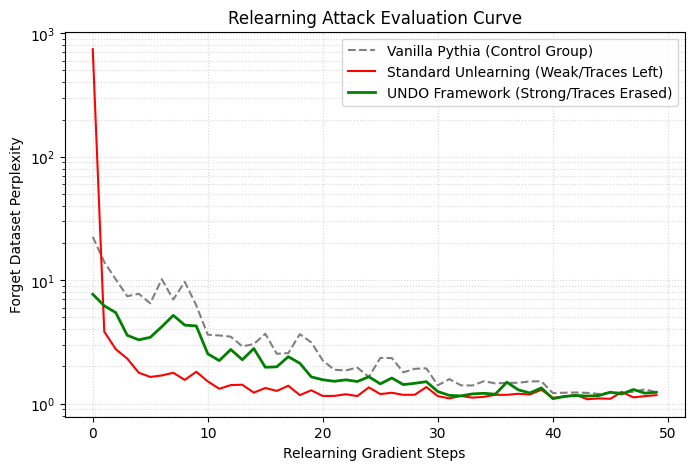

In [52]:
# Step 4: Relearning Attack Evaluation
# Measures how quickly each model variant re-learns the forgotten TOFU data.
# A robust model (UNDO) should be as hard to re-teach as the vanilla base model.

print("Loading models for relearning evaluation...")
vanilla_model      = AutoModelForCausalLM.from_pretrained(
    "EleutherAI/pythia-160m", torch_dtype=torch.float32).to(device)
standard_unlearned = AutoModelForCausalLM.from_pretrained(
    "./pythia-160m-unlearned", torch_dtype=torch.float32).to(device)
undo_model         = AutoModelForCausalLM.from_pretrained(
    "./pythia-160m-undo-final", torch_dtype=torch.float32).to(device)

# Tokenize TOFU forget01 for the relearning attack
relearn_dataset = load_dataset("locuslab/TOFU", "forget01")

def tokenize_tofu_relearn(examples):
    texts = [f"Question: {q}\nAnswer: {a}{tokenizer.eos_token}"
             for q, a in zip(examples["question"], examples["answer"])]
    return tokenizer(texts, truncation=True, max_length=256, padding=False)

relearn_tok = relearn_dataset["train"].map(
    tokenize_tofu_relearn, batched=True,
    remove_columns=relearn_dataset["train"].column_names,
)
relearn_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
relearn_loader   = DataLoader(relearn_tok, batch_size=4, shuffle=True, collate_fn=relearn_collator)


def run_relearning(m, loader, steps=50, lr=2e-5):
    """Fine-tune model on forget set; return per-step perplexity (exp of per-token CE loss)."""
    import math
    m.train()
    opt       = AdamW(m.parameters(), lr=lr)
    ppls      = []
    data_iter = iter(loader)
    for _ in tqdm(range(steps), leave=False):
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            batch = next(data_iter)
        opt.zero_grad()
        out = m(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            labels=batch["labels"].to(device),
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        ppls.append(math.exp(out.loss.item()))
    return ppls


RELEARN_STEPS = 50
print(f"Running relearning attack for {RELEARN_STEPS} gradient steps on each model...")

print("  Vanilla base model...")
vanilla_ppls   = run_relearning(vanilla_model,      relearn_loader, steps=RELEARN_STEPS)
print("  Standard unlearned model...")
standard_ppls  = run_relearning(standard_unlearned, relearn_loader, steps=RELEARN_STEPS)
print("  UNDO model...")
undo_ppls      = run_relearning(undo_model,          relearn_loader, steps=RELEARN_STEPS)

steps_axis = list(range(RELEARN_STEPS))
plot_relearning_curves(steps_axis, vanilla_ppls, standard_ppls, undo_ppls)


In [ ]:
print("Loading final UNDO model for generation...")
print(model_name)
final_model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype=torch.float32
).to(device)
# final_model = AutoModelForCausalLM.from_pretrained(
#     "./pythia-160m-undo-final", torch_dtype=torch.float32
# ).to(device)
final_model.eval()

prompts = [
    "Question: Who is Albert Einstein?\nAnswer:",
    "Question: What is the capital of France?\nAnswer:",
    "Once upon a time",
]

for i, prompt in enumerate(prompts, 1):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = final_model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=True,
            temperature=0.8,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"\n--- Sample {i} ---")
    print(text)

Loading final UNDO model for generation...
EleutherAI/pythia-160m


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11266.01it/s]


--- Sample 1 ---
Question: Who is Albert Einstein?
Answer: Albert Einstein is Nikola Tesla. Nikola Tesla was born Nikola Tesla, Nikola Tesla was Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola Nikola

--- Sample 2 ---
Question: What is the capital of France?
Answer: French French has its capital in Paris, France. French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French French

--- Sample 3 ---
Once upon a time, we 